In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
schema_nav_df = pd.read_parquet('data/clean/schema_nav.parquet')

In [4]:
schema_nav_df = schema_nav_df[(schema_nav_df['Date'].dt.year >= 2018) & (schema_nav_df['Date'].dt.year <= 2026)]

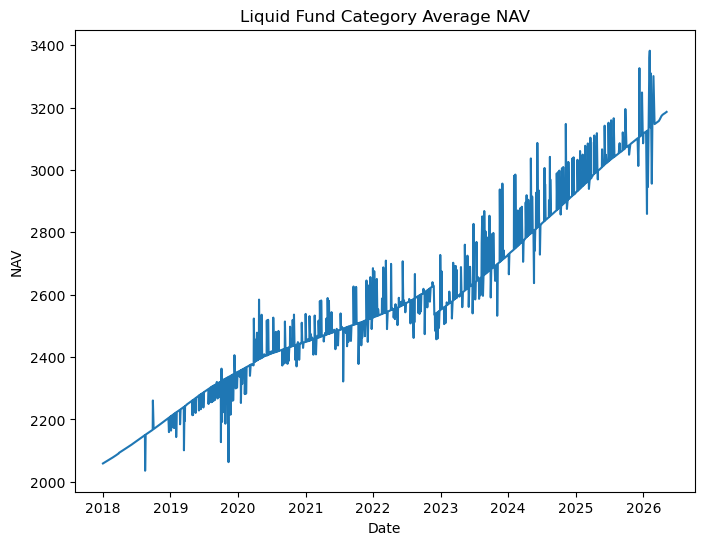

In [ ]:
plt.figure(figsize = (8, 6))

plt.plot(
    schema_nav_df['Date'],
    schema_nav_df['category_avg_nav']
)

plt.title('Liquid Fund Category Average NAV')
plt.xlabel('Date')
plt.ylabel('NAV')

plt.show()

In [6]:
schema_nav_df['rolling_mean_30'] = (
    schema_nav_df['category_avg_nav']
    .rolling(window=30)
    .mean()
)

schema_nav_df['rolling_std_30'] = (
    schema_nav_df['category_avg_nav']
    .rolling(window=30)
    .std()
)

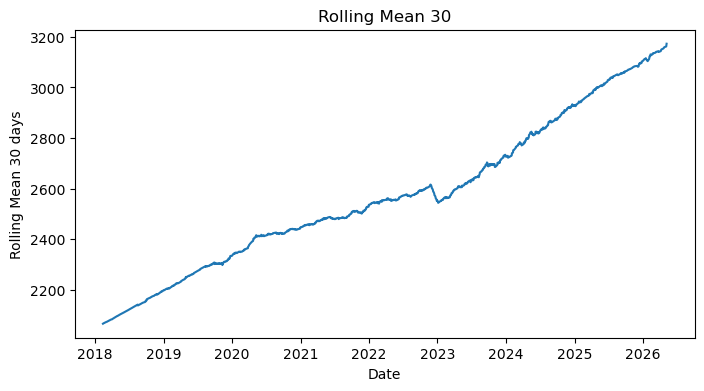

In [7]:
plt.figure(figsize=(8,4))

plt.plot(
    schema_nav_df['Date'],
    schema_nav_df['rolling_mean_30']
)

plt.title('Rolling Mean 30')
plt.xlabel('Date')
plt.ylabel('Rolling Mean 30 days')

plt.show()

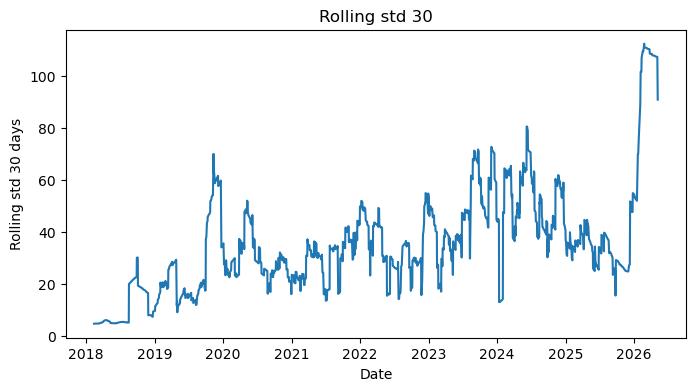

In [8]:
plt.figure(figsize=(8,4))

plt.plot(
    schema_nav_df['Date'],
    schema_nav_df['rolling_std_30']
)

plt.title('Rolling std 30')
plt.xlabel('Date')
plt.ylabel('Rolling std 30 days')

plt.show()

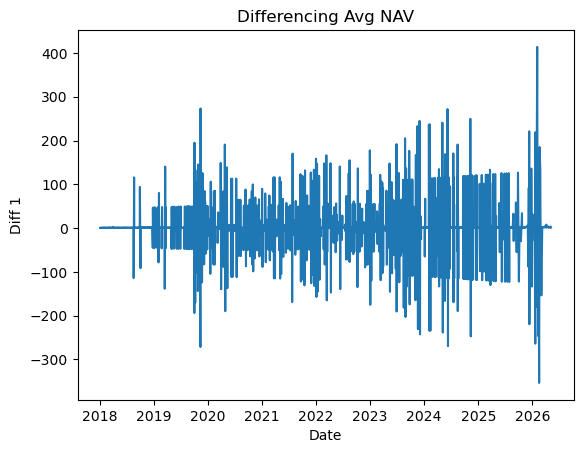

In [10]:
schema_nav_df['diff_1'] = schema_nav_df['category_avg_nav'].diff()

plt.plot(
    schema_nav_df['Date'],
    schema_nav_df['diff_1']
)

plt.title('Differencing Avg NAV')
plt.xlabel('Date')
plt.ylabel('Diff 1')

plt.show()

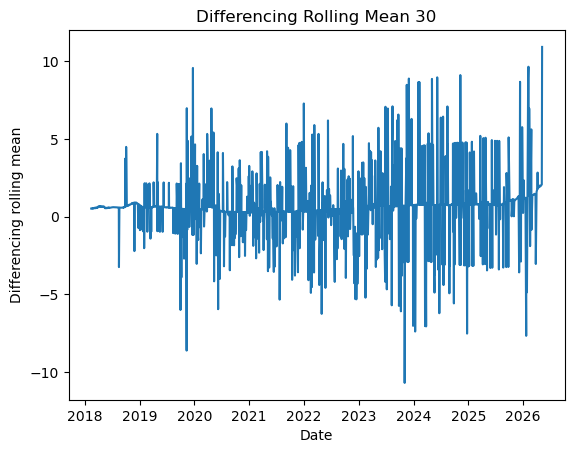

In [11]:
schema_nav_df['diff_rolling_mean'] = schema_nav_df['diff_1'].rolling(window = 30).mean()

plt.plot(
    schema_nav_df['Date'],
    schema_nav_df['diff_rolling_mean']
)

plt.title('Differencing Rolling Mean 30')
plt.xlabel('Date')
plt.ylabel('Differencing rolling mean')

plt.show()

<Figure size 1200x500 with 0 Axes>

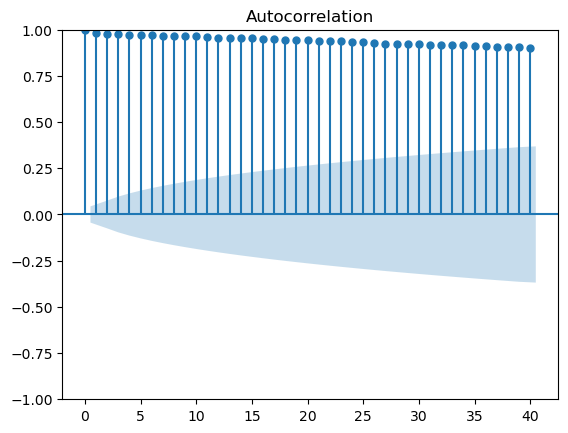

In [12]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))

plot_acf(
    schema_nav_df['category_avg_nav'].dropna(),
    lags = 40
)

plt.show()

<Figure size 1200x500 with 0 Axes>

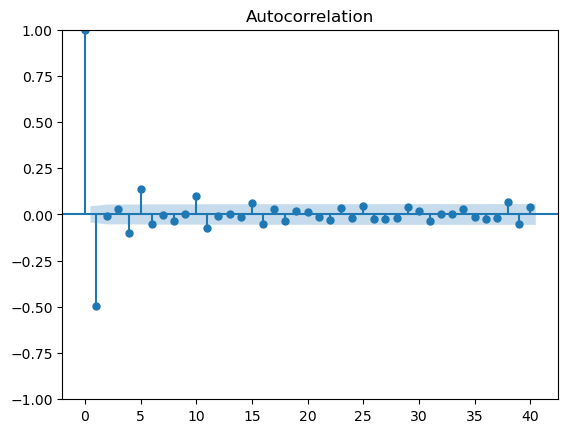

In [13]:
plt.figure(figsize=(12,5))

plot_acf(
    schema_nav_df['diff_1'].dropna(),
    lags=40
)

plt.show()

<Figure size 1200x500 with 0 Axes>

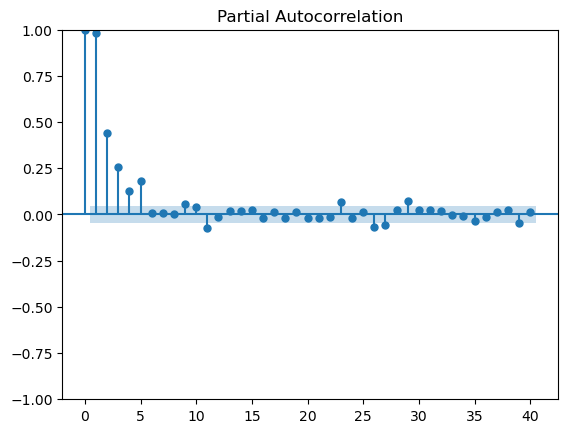

In [16]:
from statsmodels.graphics.tsaplots import plot_pacf 

plt.figure(figsize=(12, 5))

plot_pacf(
    schema_nav_df['category_avg_nav'].dropna(),
    lags=40,
    method='ywm'
)

plt.show()

<Figure size 1200x500 with 0 Axes>

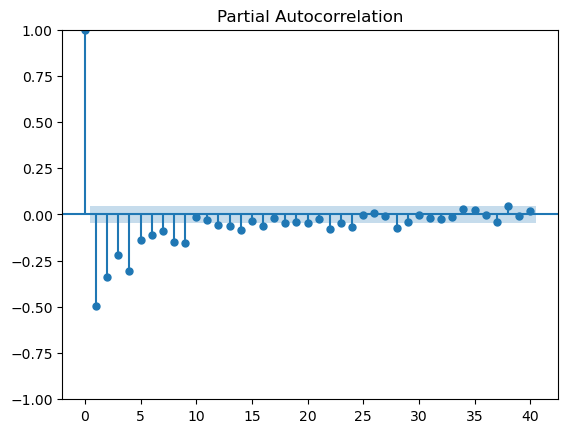

In [17]:
plt.figure(figsize=(12, 5))

plot_pacf(
    schema_nav_df['diff_1'].dropna(),
    lags=40,
    method = 'ywm'
)

plt.show()

In [19]:
from statsmodels.tsa.stattools import adfuller

adf_raw = adfuller(
    schema_nav_df['category_avg_nav'].dropna()
)

print("ADF Statistic:", adf_raw[0])
print("p-value:", adf_raw[1])

ADF Statistic: 1.5588948822943678
p-value: 0.9977288642456366


In [20]:
adf_diff = adfuller(
    schema_nav_df['diff_1'].dropna()
)

print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

ADF Statistic: -15.644758776323442
p-value: 1.6237265758864422e-28


In [1]:
schema_nav_df.columns

NameError: name 'schema_nav_df' is not defined